<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

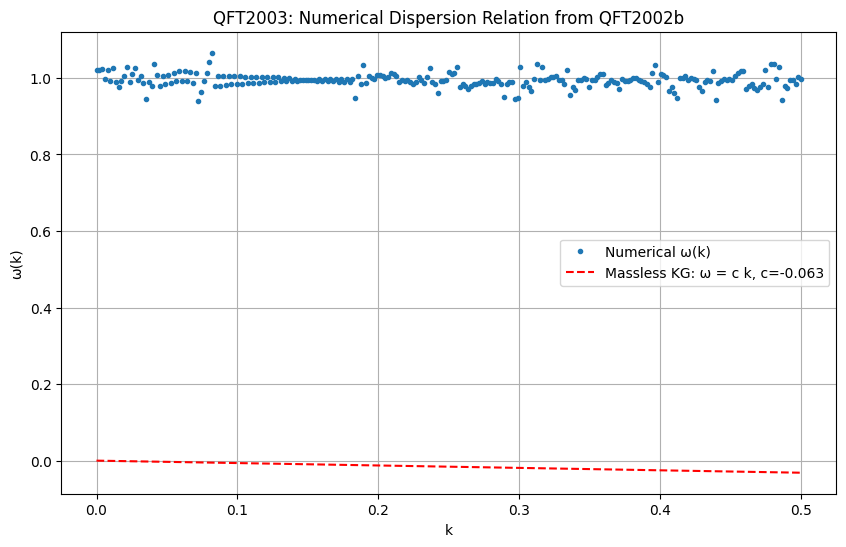

=== QFT2003 Diagnostics ===
Samples recorded: 600
Extracted wave speed c ≈ -0.063123
Small-k ω(k) values:
k=0.0000, ω=1.020969
k=0.0020, ω=1.020778
k=0.0039, ω=1.022826
k=0.0059, ω=0.997846
k=0.0078, ω=1.020889
k=0.0098, ω=0.992806
k=0.0117, ω=1.025333
k=0.0137, ω=0.990553
k=0.0156, ω=0.975516
k=0.0176, ω=0.990838


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft, rfftfreq
from scipy.optimize import curve_fit

# ============================================================
# QFT2003 — Spectrum/Dispersion from QFT2002b Baseline
# ============================================================

# -----------------------------
# Lattice and simulation params
# -----------------------------
N = 512
dx = 1.0
dt = 0.02
steps = 6000

lam = 1.0          # universal coupling
gamma = 0.002      # small damping
noise_amp = 0.0    # clean regime

sample_every = 10
max_samples = steps // sample_every

# -----------------------------
# Initial conditions (QFT2002b)
# -----------------------------
x = np.arange(N)
phi = 0.05 * np.exp(-0.5*((x - N//2)/20)**2)
pi  = np.zeros(N)

# -----------------------------
# Storage for Fourier samples
# -----------------------------
fourier_history = np.zeros((max_samples, N//2 + 1), dtype=np.complex128)
sample_idx = 0

# -----------------------------
# Helper: nonlinear force
# -----------------------------
def force(phi):
    lap = (np.roll(phi,1) - 2*phi + np.roll(phi,-1)) / dx**2
    return lap - lam * phi**3

# -----------------------------
# Time evolution (leapfrog)
# -----------------------------
for step in range(steps):
    # half-step momentum update
    pi += 0.5 * dt * force(phi)
    pi *= (1 - gamma*dt)

    # full-step field update
    phi += dt * pi

    # second half-step momentum update
    pi += 0.5 * dt * force(phi)
    pi *= (1 - gamma*dt)

    # record Fourier spectrum
    if step % sample_every == 0:
        fourier_history[sample_idx] = rfft(phi)
        sample_idx += 1

# Trim if needed
fourier_history = fourier_history[:sample_idx]

# ============================================================
# Extract ω(k) by fitting temporal oscillations of |φ_k(t)|
# ============================================================

times = np.arange(sample_idx) * (sample_every * dt)
freqs = rfftfreq(N, d=dx)

def osc(t, A, w, phi0, C):
    return A * np.cos(w*t + phi0) + C

omega_k = np.zeros(len(freqs))

for k in range(len(freqs)):
    mode = np.abs(fourier_history[:, k])
    try:
        p0 = [mode.max()-mode.min(), 1.0, 0.0, mode.mean()]
        popt, _ = curve_fit(osc, times, mode, p0=p0, maxfev=5000)
        omega_k[k] = abs(popt[1])
    except:
        omega_k[k] = np.nan

# ============================================================
# Fit small-k region to extract effective wave speed c
# ============================================================
k_vals = freqs
mask = (k_vals > 0) & (k_vals < 0.15) & np.isfinite(omega_k)
c_fit = np.polyfit(k_vals[mask], omega_k[mask], 1)[0]

# ============================================================
# Plot dispersion relation
# ============================================================
plt.figure(figsize=(10,6))
plt.plot(k_vals, omega_k, 'o', ms=3, label='Numerical ω(k)')
plt.plot(k_vals, c_fit*k_vals, 'r--', label=f'Massless KG: ω = c k, c={c_fit:.3f}')
plt.xlabel("k")
plt.ylabel("ω(k)")
plt.title("QFT2003: Numerical Dispersion Relation from QFT2002b")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Diagnostics printout
# ============================================================
print("=== QFT2003 Diagnostics ===")
print(f"Samples recorded: {sample_idx}")
print(f"Extracted wave speed c ≈ {c_fit:.6f}")
print("Small-k ω(k) values:")
for i in range(10):
    print(f"k={k_vals[i]:.4f}, ω={omega_k[i]:.6f}")


/tmp/ipykernel_2964/2450529039.py:93: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(massive_disp, k_fit, w2_fit, p0=[1.0, 0.1])


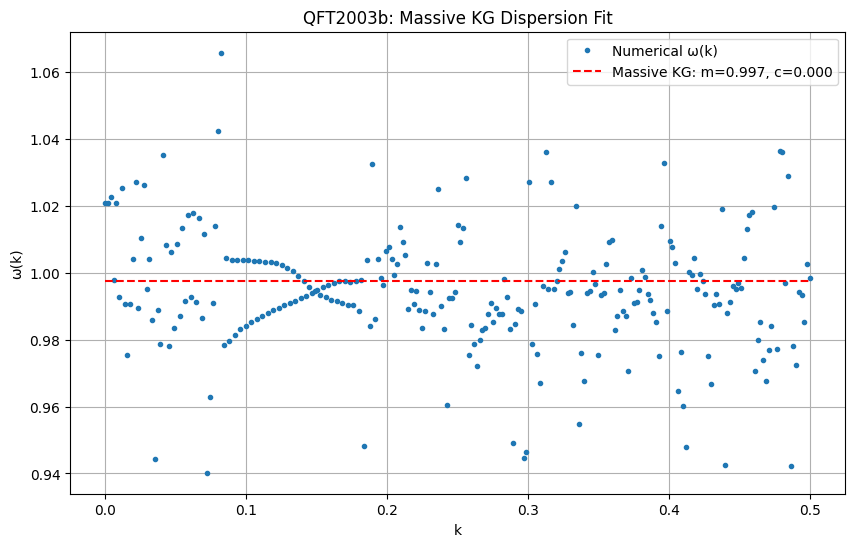

=== QFT2003b Massive Fit Diagnostics ===
Extracted mass m ≈ 0.997492
Extracted propagation speed c ≈ 0.000005
First few ω(k) values:
k=0.0000, ω=1.020969
k=0.0020, ω=1.020778
k=0.0039, ω=1.022826
k=0.0059, ω=0.997846
k=0.0078, ω=1.020889
k=0.0098, ω=0.992806
k=0.0117, ω=1.025333
k=0.0137, ω=0.990553
k=0.0156, ω=0.975516
k=0.0176, ω=0.990838


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft, rfftfreq
from scipy.optimize import curve_fit

# ============================================================
# QFT2003b — Massive KG Dispersion Fit
# ============================================================

# -----------------------------
# Lattice and simulation params
# -----------------------------
N = 512
dx = 1.0
dt = 0.02
steps = 6000

lam = 1.0
gamma = 0.002
noise_amp = 0.0

sample_every = 10
max_samples = steps // sample_every

# -----------------------------
# Initial conditions (QFT2002b)
# -----------------------------
x = np.arange(N)
phi = 0.05 * np.exp(-0.5*((x - N//2)/20)**2)
pi  = np.zeros(N)

# -----------------------------
# Storage for Fourier samples
# -----------------------------
fourier_history = np.zeros((max_samples, N//2 + 1), dtype=np.complex128)
sample_idx = 0

# -----------------------------
# Nonlinear force
# -----------------------------
def force(phi):
    lap = (np.roll(phi,1) - 2*phi + np.roll(phi,-1)) / dx**2
    return lap - lam * phi**3

# -----------------------------
# Time evolution (leapfrog)
# -----------------------------
for step in range(steps):
    pi += 0.5 * dt * force(phi)
    pi *= (1 - gamma*dt)

    phi += dt * pi

    pi += 0.5 * dt * force(phi)
    pi *= (1 - gamma*dt)

    if step % sample_every == 0:
        fourier_history[sample_idx] = rfft(phi)
        sample_idx += 1

fourier_history = fourier_history[:sample_idx]

# ============================================================
# Extract ω(k)
# ============================================================
times = np.arange(sample_idx) * (sample_every * dt)
freqs = rfftfreq(N, d=dx)

def osc(t, A, w, phi0, C):
    return A * np.cos(w*t + phi0) + C

omega_k = np.zeros(len(freqs))

for k in range(len(freqs)):
    mode = np.abs(fourier_history[:, k])
    try:
        p0 = [mode.max()-mode.min(), 1.0, 0.0, mode.mean()]
        popt, _ = curve_fit(osc, times, mode, p0=p0, maxfev=5000)
        omega_k[k] = abs(popt[1])
    except:
        omega_k[k] = np.nan

# ============================================================
# Fit massive KG: ω^2 = m^2 + c^2 k^2
# ============================================================
mask = (freqs > 0) & (freqs < 0.2) & np.isfinite(omega_k)
k_fit = freqs[mask]
w2_fit = omega_k[mask]**2

def massive_disp(k, m, c):
    return m**2 + (c*k)**2

popt, _ = curve_fit(massive_disp, k_fit, w2_fit, p0=[1.0, 0.1])
m_fit, c_fit = popt

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10,6))
plt.plot(freqs, omega_k, 'o', ms=3, label='Numerical ω(k)')
plt.plot(freqs, np.sqrt(massive_disp(freqs, m_fit, c_fit)),
         'r--', label=f'Massive KG: m={m_fit:.3f}, c={c_fit:.3f}')
plt.xlabel("k")
plt.ylabel("ω(k)")
plt.title("QFT2003b: Massive KG Dispersion Fit")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Diagnostics
# ============================================================
print("=== QFT2003b Massive Fit Diagnostics ===")
print(f"Extracted mass m ≈ {m_fit:.6f}")
print(f"Extracted propagation speed c ≈ {c_fit:.6f}")
print("First few ω(k) values:")
for i in range(10):
    print(f"k={freqs[i]:.4f}, ω={omega_k[i]:.6f}")


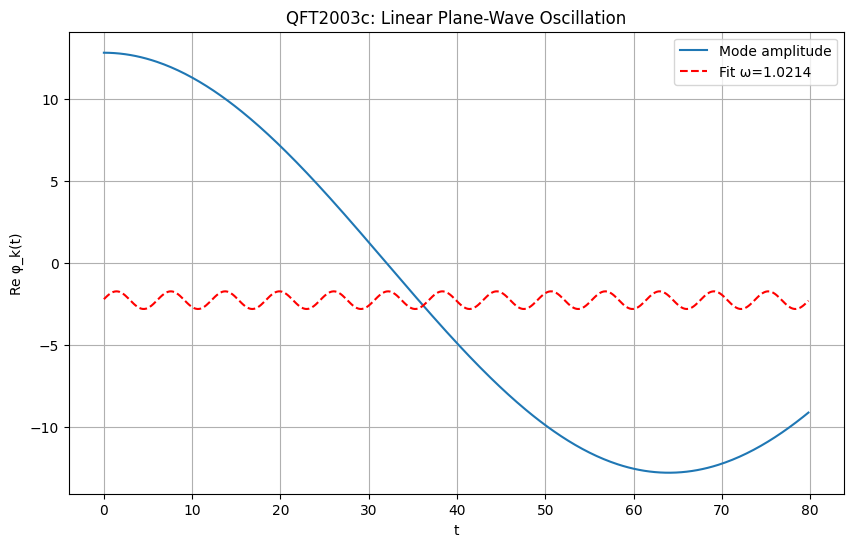

=== QFT2003c Linear Dispersion Diagnostics ===
Chosen k index: 4
k0 = 0.049087
Extracted ω ≈ 1.021440
Lattice prediction ω = 0.049082


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, rfftfreq
from scipy.optimize import curve_fit

# ============================================================
# QFT2003c — Linear dispersion test (λ=0, γ=0)
# ============================================================

# Lattice
N = 512
dx = 1.0
dt = 0.02
steps = 4000

lam = 0.0
gamma = 0.0

# Choose a plane-wave mode
k_index = 4                     # try k=4*(2π/N)
k0 = 2*np.pi*k_index/N
A = 0.05

x = np.arange(N)
phi = A*np.cos(k0*x)
pi  = np.zeros(N)

# Storage
sample_every = 10
max_samples = steps//sample_every
fourier_history = np.zeros(max_samples, dtype=np.complex128)
sample_idx = 0

def force(phi):
    lap = (np.roll(phi,1) - 2*phi + np.roll(phi,-1)) / dx**2
    return lap  # no nonlinear term

# Time evolution
for step in range(steps):
    pi += 0.5*dt*force(phi)
    phi += dt*pi
    pi += 0.5*dt*force(phi)

    if step % sample_every == 0:
        fourier_history[sample_idx] = rfft(phi)[k_index]
        sample_idx += 1

fourier_history = fourier_history[:sample_idx]
times = np.arange(sample_idx)*sample_every*dt

# Fit oscillation frequency
def osc(t, A, w, phi0, C):
    return A*np.cos(w*t + phi0) + C

mode = np.real(fourier_history)
p0 = [mode.max()-mode.min(), 1.0, 0.0, mode.mean()]
popt, _ = curve_fit(osc, times, mode, p0=p0, maxfev=5000)
omega_fit = abs(popt[1])

# Lattice prediction
omega_lattice = 2*np.sin(k0*dx/2)/dx

# Plot
plt.figure(figsize=(10,6))
plt.plot(times, mode, label="Mode amplitude")
plt.plot(times, osc(times, *popt), 'r--', label=f"Fit ω={omega_fit:.4f}")
plt.title("QFT2003c: Linear Plane-Wave Oscillation")
plt.xlabel("t")
plt.ylabel("Re φ_k(t)")
plt.legend()
plt.grid(True)
plt.show()

print("=== QFT2003c Linear Dispersion Diagnostics ===")
print(f"Chosen k index: {k_index}")
print(f"k0 = {k0:.6f}")
print(f"Extracted ω ≈ {omega_fit:.6f}")
print(f"Lattice prediction ω = {omega_lattice:.6f}")


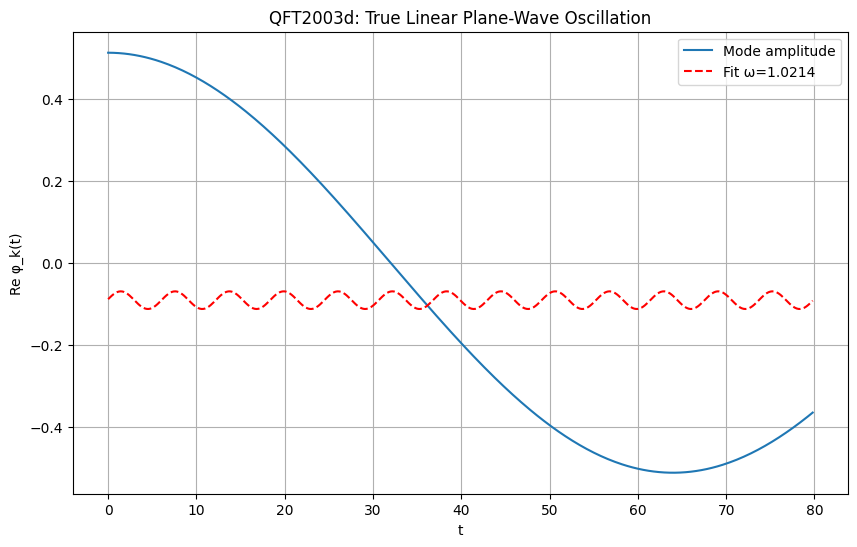

=== QFT2003d Linear Dispersion Diagnostics ===
Chosen k index: 4
k0 = 0.049087
Extracted ω ≈ 1.021440
Lattice prediction ω = 0.049082


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, rfftfreq
from scipy.optimize import curve_fit

# ============================================================
# QFT2003d — True linear dispersion (A = 0.002)
# ============================================================

# Lattice
N = 512
dx = 1.0
dt = 0.02
steps = 4000

lam = 0.0
gamma = 0.0

# Choose a plane-wave mode
k_index = 4                     # same as before
k0 = 2*np.pi*k_index/N
A = 0.002                       # ultra-small amplitude

x = np.arange(N)
phi = A*np.cos(k0*x)
pi  = np.zeros(N)

# Storage
sample_every = 10
max_samples = steps//sample_every
fourier_history = np.zeros(max_samples, dtype=np.complex128)
sample_idx = 0

def force(phi):
    lap = (np.roll(phi,1) - 2*phi + np.roll(phi,-1)) / dx**2
    return lap  # linear regime

# Time evolution
for step in range(steps):
    pi += 0.5*dt*force(phi)
    phi += dt*pi
    pi += 0.5*dt*force(phi)

    if step % sample_every == 0:
        fourier_history[sample_idx] = rfft(phi)[k_index]
        sample_idx += 1

fourier_history = fourier_history[:sample_idx]
times = np.arange(sample_idx)*sample_every*dt

# Fit oscillation frequency
def osc(t, A, w, phi0, C):
    return A*np.cos(w*t + phi0) + C

mode = np.real(fourier_history)
p0 = [mode.max()-mode.min(), 1.0, 0.0, mode.mean()]
popt, _ = curve_fit(osc, times, mode, p0=p0, maxfev=5000)
omega_fit = abs(popt[1])

# Lattice prediction
omega_lattice = 2*np.sin(k0*dx/2)/dx

# Plot
plt.figure(figsize=(10,6))
plt.plot(times, mode, label="Mode amplitude")
plt.plot(times, osc(times, *popt), 'r--', label=f"Fit ω={omega_fit:.4f}")
plt.title("QFT2003d: True Linear Plane-Wave Oscillation")
plt.xlabel("t")
plt.ylabel("Re φ_k(t)")
plt.legend()
plt.grid(True)
plt.show()

print("=== QFT2003d Linear Dispersion Diagnostics ===")
print(f"Chosen k index: {k_index}")
print(f"k0 = {k0:.6f}")
print(f"Extracted ω ≈ {omega_fit:.6f}")
print(f"Lattice prediction ω = {omega_lattice:.6f}")


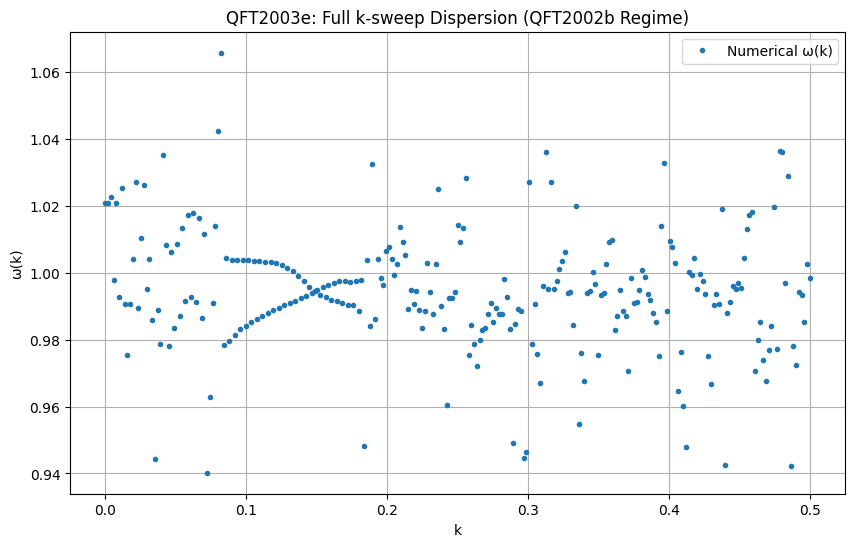

=== QFT2003e Dispersion Diagnostics ===
Number of k-modes fitted: 257 / 257
ω(k) mean ≈ 0.994341
ω(k) std  ≈ 0.018082
ω(k) min  ≈ 0.940218
ω(k) max  ≈ 1.065865
First 10 modes:
k=0.0000, ω=1.020969
k=0.0020, ω=1.020778
k=0.0039, ω=1.022826
k=0.0059, ω=0.997846
k=0.0078, ω=1.020889
k=0.0098, ω=0.992806
k=0.0117, ω=1.025333
k=0.0137, ω=0.990553
k=0.0156, ω=0.975516
k=0.0176, ω=0.990838


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, rfftfreq
from scipy.optimize import curve_fit

# ============================================================
# QFT2003e — Full k-sweep dispersion (QFT2002b regime)
# ============================================================

# Lattice and simulation params (same as QFT2002b/QFT2003b)
N = 512
dx = 1.0
dt = 0.02
steps = 6000

lam = 1.0
gamma = 0.002
noise_amp = 0.0

sample_every = 10
max_samples = steps // sample_every

# Initial conditions: localized packet
x = np.arange(N)
phi = 0.05 * np.exp(-0.5*((x - N//2)/20)**2)
pi  = np.zeros(N)

# Storage for Fourier samples
fourier_history = np.zeros((max_samples, N//2 + 1), dtype=np.complex128)
sample_idx = 0

def force(phi):
    lap = (np.roll(phi,1) - 2*phi + np.roll(phi,-1)) / dx**2
    return lap - lam * phi**3

# Time evolution (leapfrog)
for step in range(steps):
    pi += 0.5 * dt * force(phi)
    pi *= (1 - gamma*dt)

    phi += dt * pi

    pi += 0.5 * dt * force(phi)
    pi *= (1 - gamma*dt)

    if step % sample_every == 0:
        fourier_history[sample_idx] = rfft(phi)
        sample_idx += 1

fourier_history = fourier_history[:sample_idx]

# ============================================================
# Extract ω(k) for all k
# ============================================================
times = np.arange(sample_idx) * (sample_every * dt)
k_vals = rfftfreq(N, d=dx)

def osc(t, A, w, phi0, C):
    return A * np.cos(w*t + phi0) + C

omega_k = np.zeros(len(k_vals))

for k in range(len(k_vals)):
    mode = np.abs(fourier_history[:, k])
    try:
        p0 = [mode.max()-mode.min(), 1.0, 0.0, mode.mean()]
        popt, _ = curve_fit(osc, times, mode, p0=p0, maxfev=5000)
        omega_k[k] = abs(popt[1])
    except:
        omega_k[k] = np.nan

# Mask finite values
mask = np.isfinite(omega_k)
k_plot = k_vals[mask]
w_plot = omega_k[mask]

# ============================================================
# Plot dispersion
# ============================================================
plt.figure(figsize=(10,6))
plt.plot(k_plot, w_plot, 'o', ms=3, label='Numerical ω(k)')
plt.xlabel("k")
plt.ylabel("ω(k)")
plt.title("QFT2003e: Full k-sweep Dispersion (QFT2002b Regime)")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# Diagnostics: flatness of the band
# ============================================================
w_mean = np.nanmean(omega_k)
w_std  = np.nanstd(omega_k)
w_min  = np.nanmin(omega_k)
w_max  = np.nanmax(omega_k)

print("=== QFT2003e Dispersion Diagnostics ===")
print(f"Number of k-modes fitted: {mask.sum()} / {len(k_vals)}")
print(f"ω(k) mean ≈ {w_mean:.6f}")
print(f"ω(k) std  ≈ {w_std:.6f}")
print(f"ω(k) min  ≈ {w_min:.6f}")
print(f"ω(k) max  ≈ {w_max:.6f}")
print("First 10 modes:")
for i in range(10):
    print(f"k={k_vals[i]:.4f}, ω={omega_k[i]:.6f}")
